### DRAGON Test Results Processing
#### Isaac Moskowitz & Jeremy Ng
#### C. Meg Urry and Aritra Ghosh
#### July 2nd, 2024

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch.nn as nn
import logging
import pandas as pd
import csv
import sys
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import cross_val_score 
from keras import backend as K
import os
from os.path import exists
from tqdm import tqdm
import glob
from astropy.wcs import WCS
#import tensorflow_addons as tfa
import shutil
#from dual_finder import DualFinder, loadModelClass
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

gpu = len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "available" if gpu else "NOT AVAILABLE")
print(tf.config.list_physical_devices())
from tensorflow.python.client import device_lib 
print(device_lib.list_local_devices())
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
from astropy.io import fits

sys.path.append("DRAGON_Dual_Finder/dual_finder/cnn/")
sys.path.append("DRAGON_Dual_Finder/dual_finder/optimize/")
sys.path.append("DRAGON_Dual_Finder/dual_finder/preprocess_data/")
sys.path.append("DRAGON_Dual_Finder/dual_finder/visualize/")
from create_cnn import ModelCreator
from load_model import loadModelClass
from train_cnn import DualFinder
from extract_feature_maps import FeatureExtractor
from fits_utils import plot_dataset_sample
from process_data import make_datasets_other_bands, create_dataset, crop_center
from optimize_hyperparameters import OptimizeHyperparameters
from visualize_performance import load_training_history, plot_training_progress, plot_grouped_training_progress, VisualizeOptimization
from inference_tests import testResults

2024-07-02 14:47:11.859402: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-02 14:47:12.697309: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-02 14:47:12.697357: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-02 14:47:12.702679: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-02 14:47:13.145126: I tensorflow/core/platform/cpu_feature_g

GPU is NOT AVAILABLE
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 1920419197393545200
xla_global_id: -1
]


2024-07-02 14:47:31.221214: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
#len("data_preprocessing/training_datasets/")
test_images = []
test_image_names = []
for ii, image_file in tqdm(enumerate(glob.glob("hsc_2626_test_HSC-G/*.fits"))):
    try:
        with fits.open(image_file, memmap=False) as hdul:
            img = hdul[1].data
            img = crop_center(img, 94, 94)
            test_images.append(img)
            test_image_names.append(image_file)
    except OSError:
        print(f"file {image_file} has become corrupted.")
test_images = np.expand_dims(test_images, axis = -1)
print(test_images.shape)

2601it [00:07, 330.95it/s]

(2601, 94, 94, 1)


In [3]:
saved_model_filepath = "../combined_model_test_1/saved_model_20.h5"
#saved_model_filepath = "../combined_model_test_4/saved_model_25.h5"
#saved_model_filepath = "../dual_merger_saved_dual_finder_models_test_sgd/saved_model_30.h5"\
#saved_model_filepath = "../dual_merger_saved_dual_finder_models_test_4/saved_model_30.h5"
dual_finder_model = tf.keras.models.load_model(saved_model_filepath, compile=True, safe_mode=True)
history = load_training_history("../combined_model_test_1/saved_history.npy")

82/82 [==============================] - 33s 397ms/step


0it [00:00, ?it/s]

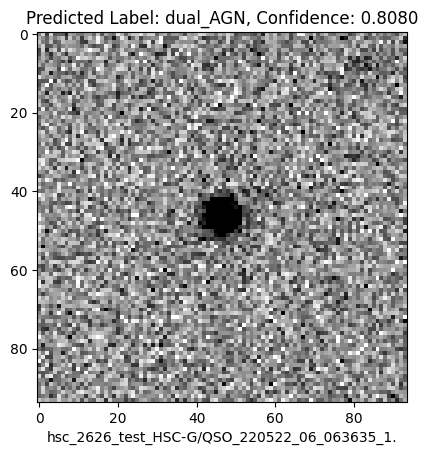

218it [00:00, 684.34it/s]

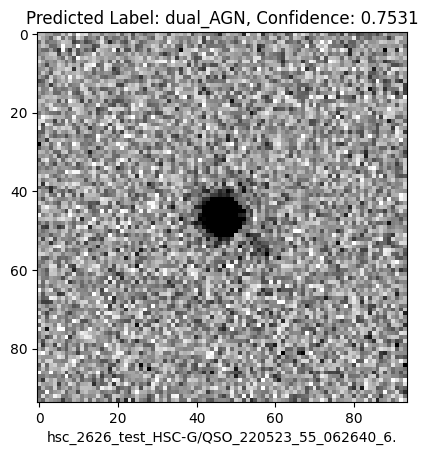

287it [00:00, 492.07it/s]

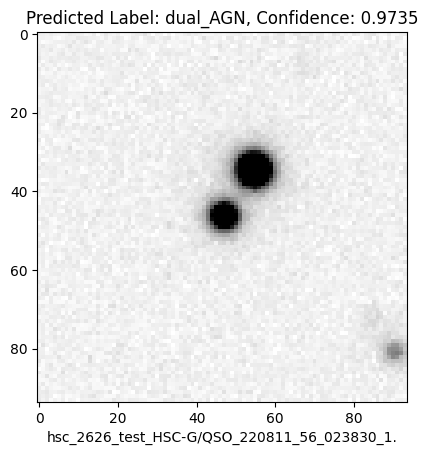

632it [00:00, 938.04it/s]

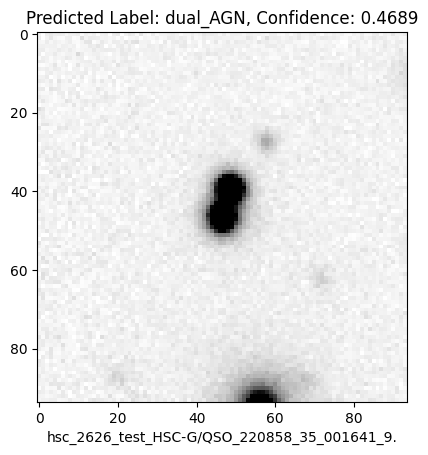

752it [00:00, 796.47it/s]

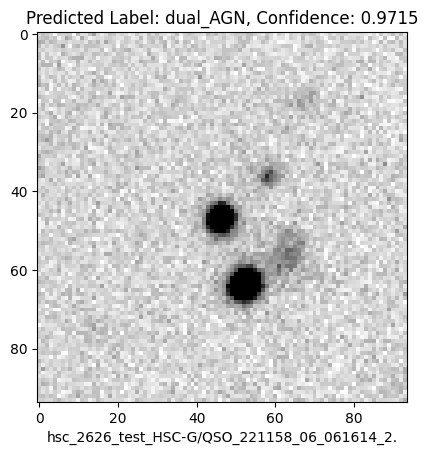

1215it [00:01, 1251.45it/s]

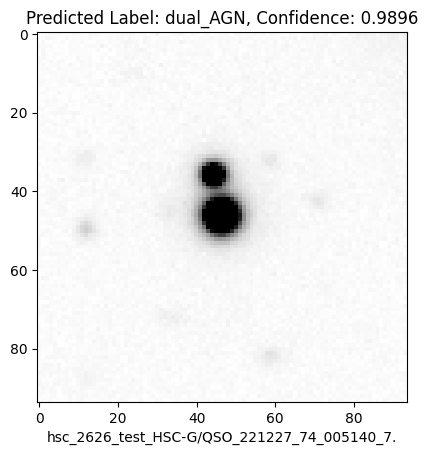

1343it [00:01, 1036.72it/s]

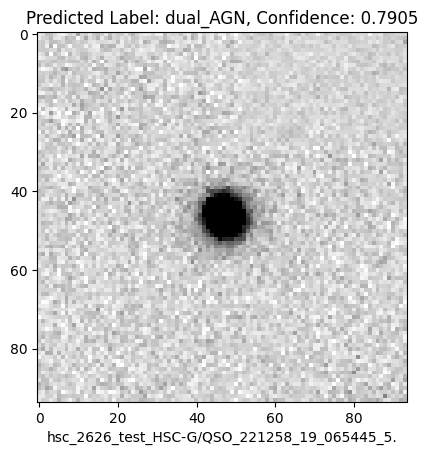

1448it [00:01, 860.75it/s] 

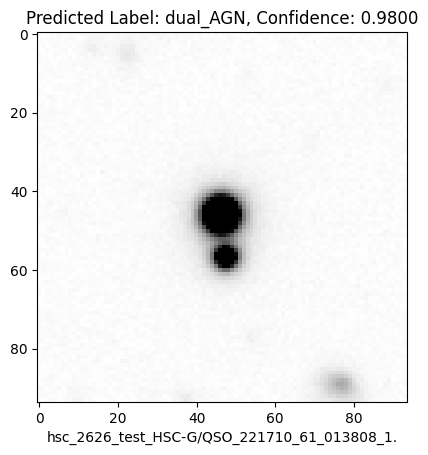

1975it [00:01, 1341.38it/s]

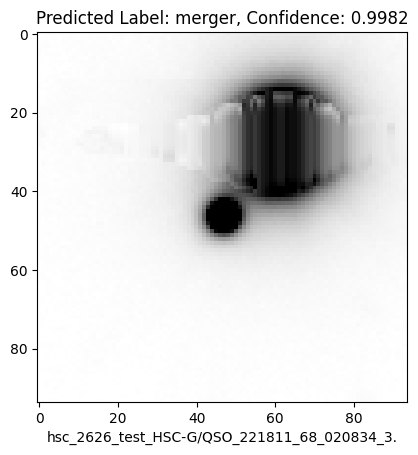

2116it [00:02, 1092.54it/s]

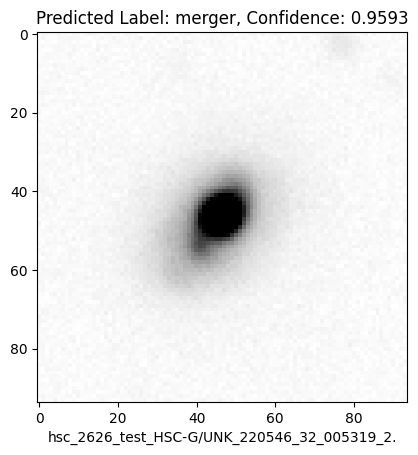

2396it [00:02, 1083.62it/s]

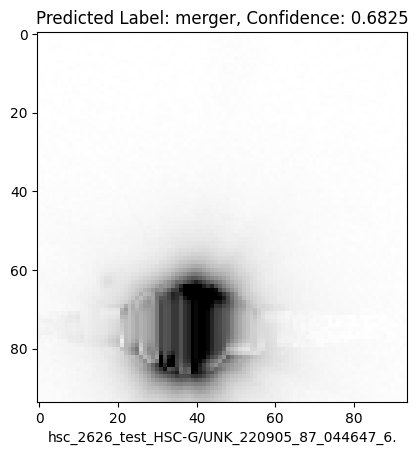

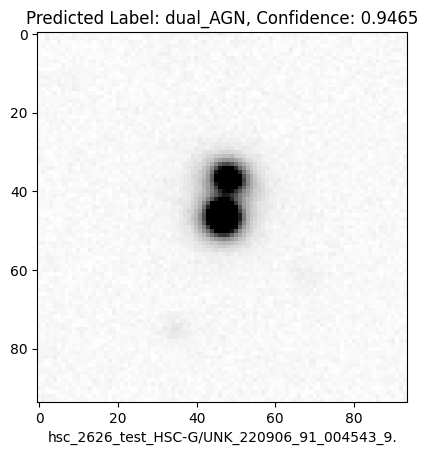

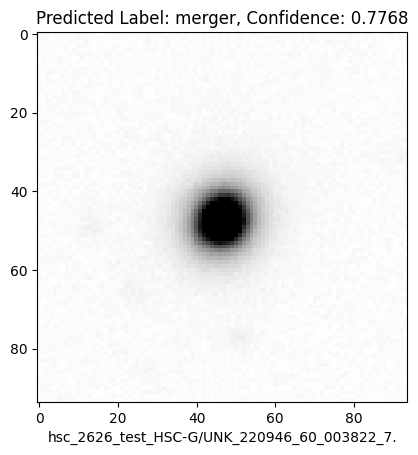

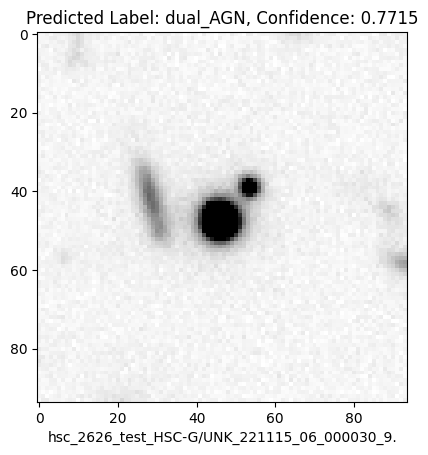

2506it [00:03, 498.69it/s] 

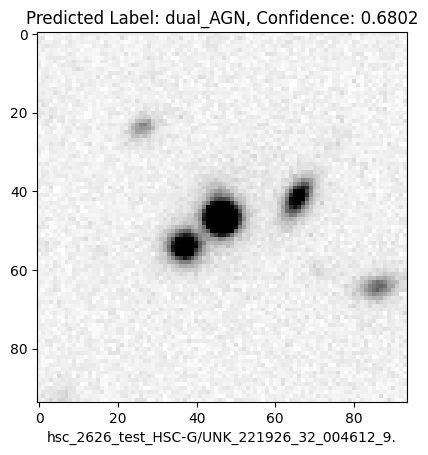

2591it [00:03, 470.28it/s]

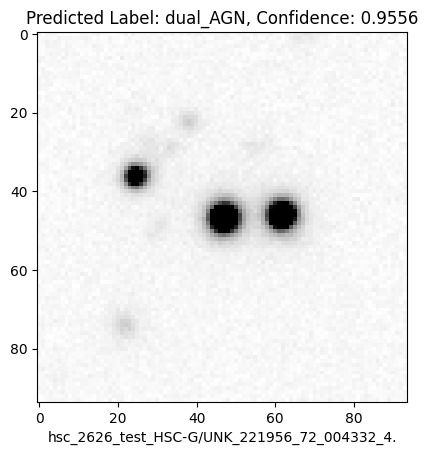

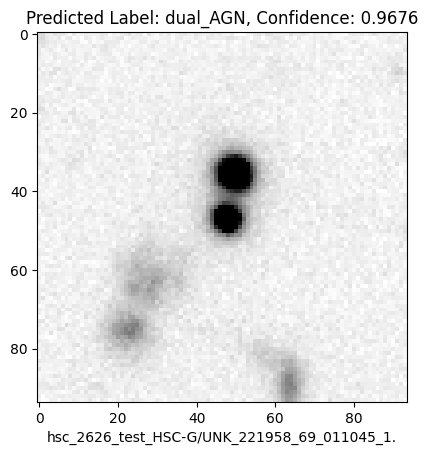

2601it [00:03, 670.04it/s]


object_ID     hsc_2626_test_HSC-G/QSO_220811_56_023830_1.fits
label                                                dual_AGN
confidence                                           0.973499
Name: 631, dtype: object
object_ID     hsc_2626_test_HSC-G/UNK_220718_43_001723_1.fits
label                                              single_AGN
confidence                                           0.566659
Name: 2412, dtype: object
object_ID     hsc_2626_test_HSC-G/UNK_220906_91_004543_9.fits
label                                                dual_AGN
confidence                                           0.946512
Name: 2438, dtype: object
object_ID     hsc_2626_test_HSC-G/UNK_221115_06_000030_9.fits
label                                                dual_AGN
confidence                                           0.771541
Name: 2477, dtype: object
Number of dual AGN:  13
Number of single AGN:  2584
Number of megers:  4
Number of empty space:  0
2584


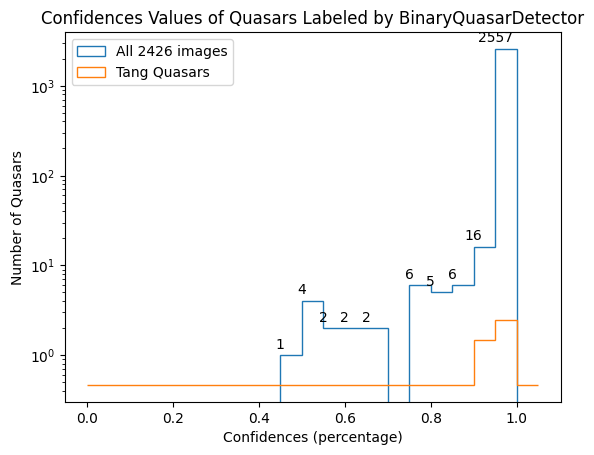

(17, 94, 94)


0it [00:00, ?it/s]

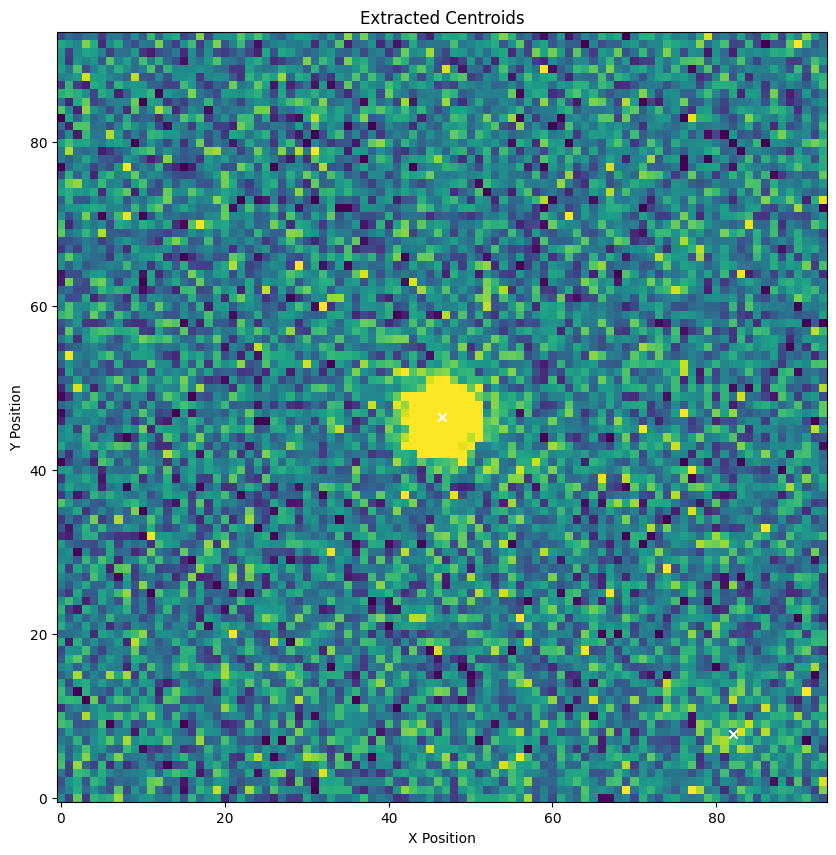

1it [00:00,  5.66it/s]

Image hsc_2626_test_HSC-G/QSO_220522_06_063635_1.fits - Number of sources detected: 2


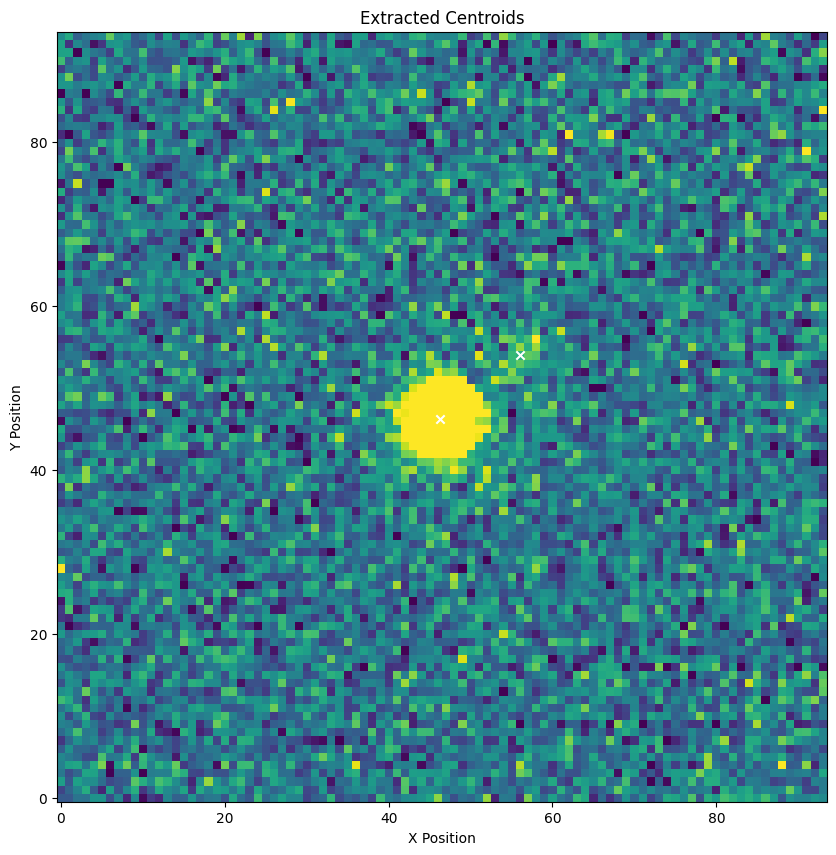

2it [00:00,  5.53it/s]

Image hsc_2626_test_HSC-G/QSO_220523_55_062640_6.fits - Number of sources detected: 2


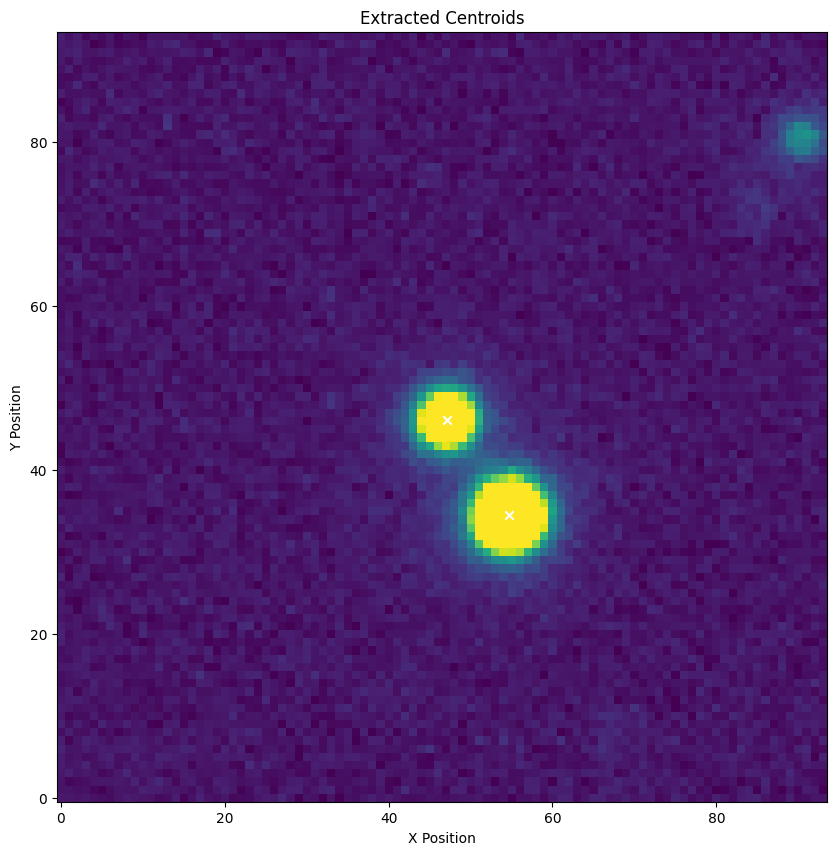

3it [00:00,  5.55it/s]

Image hsc_2626_test_HSC-G/QSO_220811_56_023830_1.fits - Number of sources detected: 83


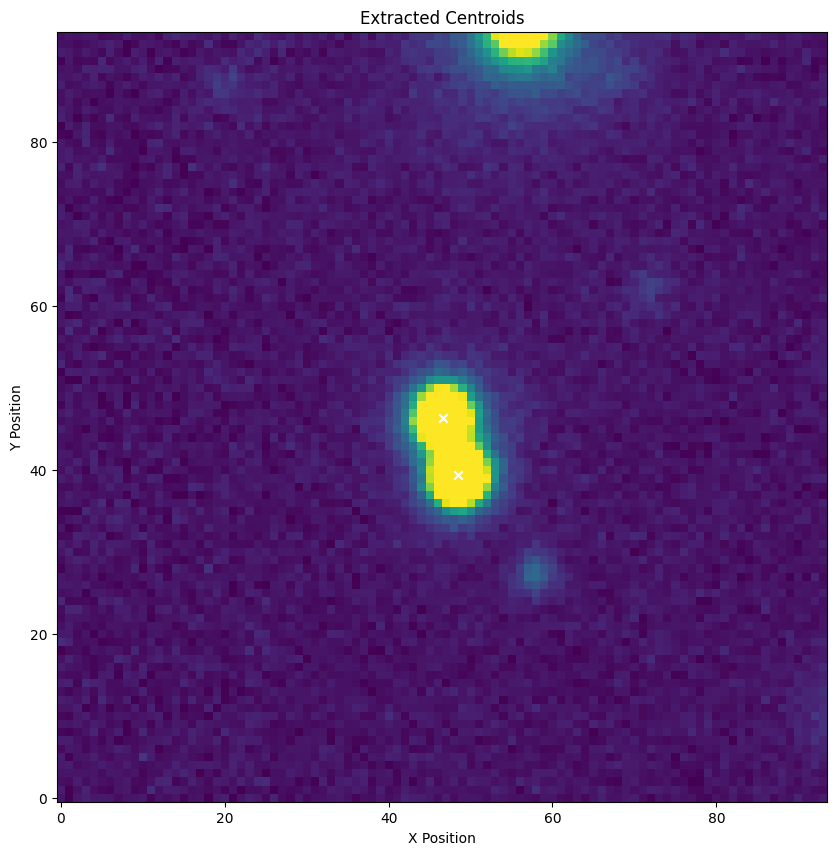

4it [00:00,  5.62it/s]

Image hsc_2626_test_HSC-G/QSO_220858_35_001641_9.fits - Number of sources detected: 79


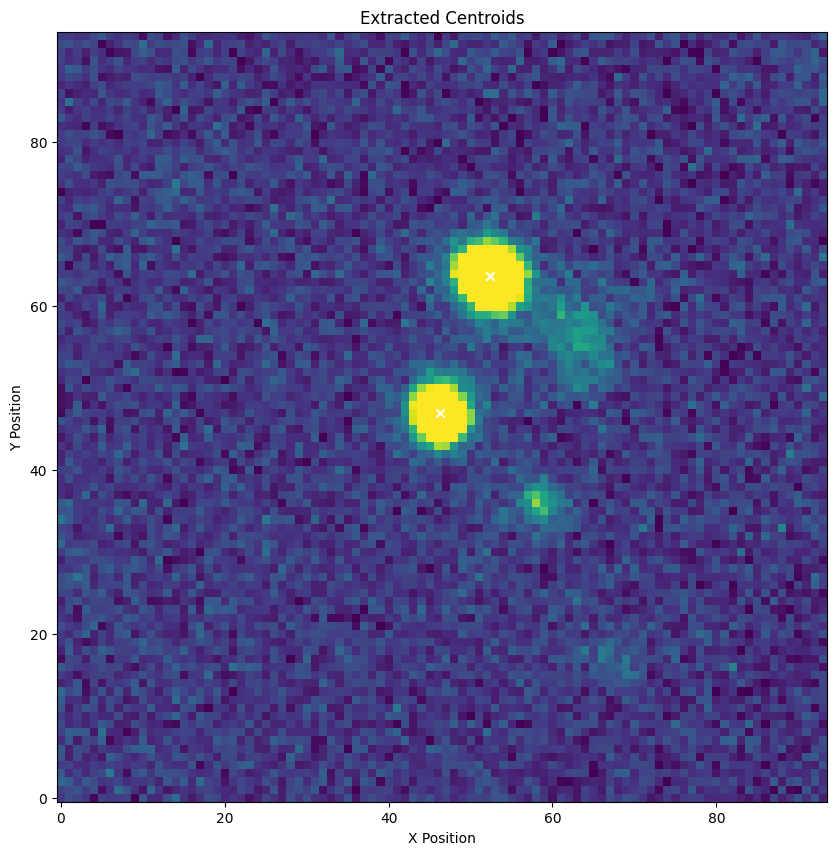

5it [00:00,  5.72it/s]

Image hsc_2626_test_HSC-G/QSO_221158_06_061614_2.fits - Number of sources detected: 58


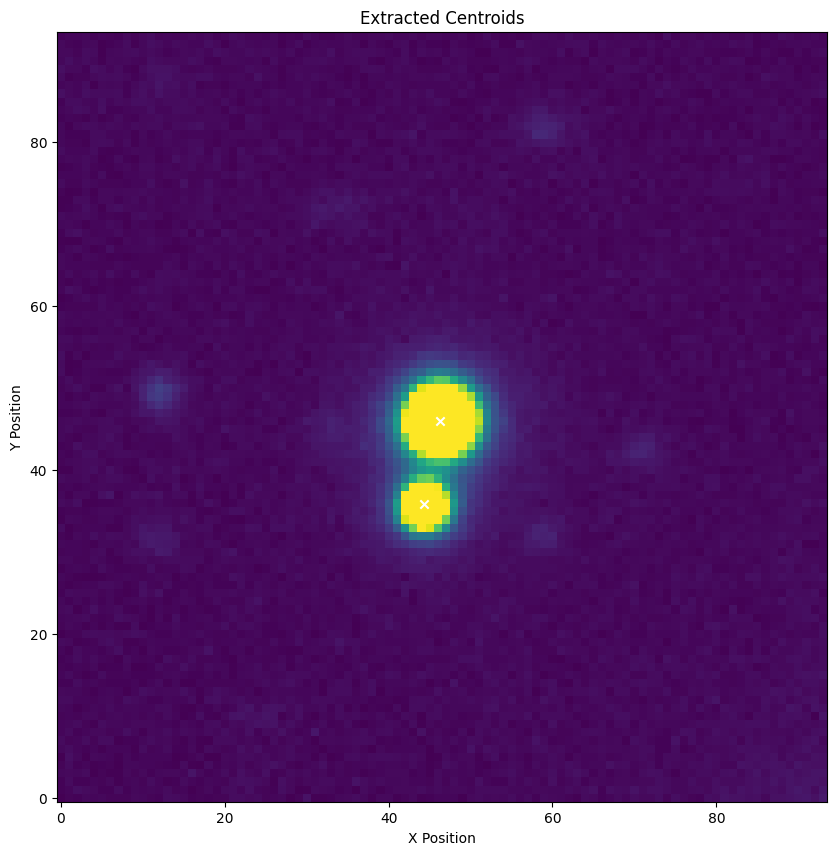

6it [00:01,  5.72it/s]

Image hsc_2626_test_HSC-G/QSO_221227_74_005140_7.fits - Number of sources detected: 61


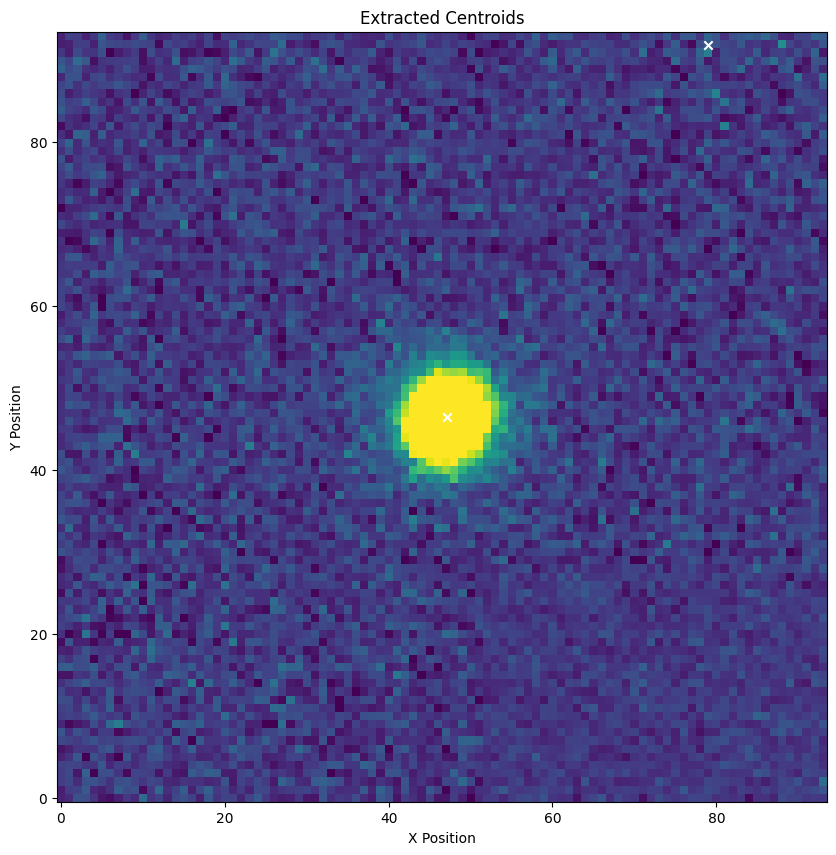

7it [00:01,  5.81it/s]

Image hsc_2626_test_HSC-G/QSO_221258_19_065445_5.fits - Number of sources detected: 8


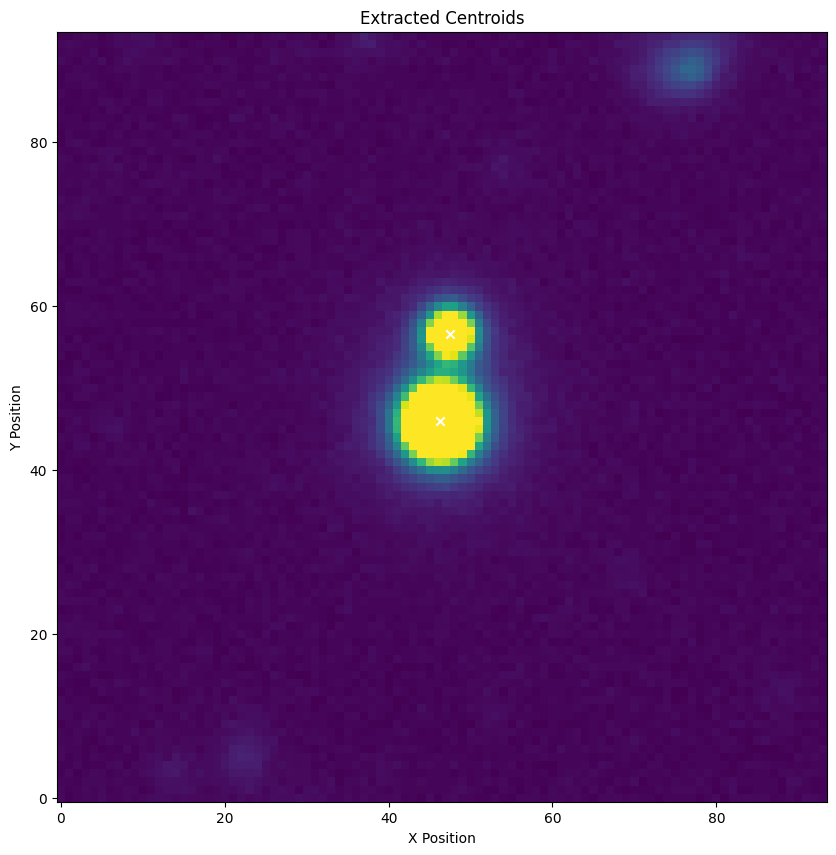

8it [00:01,  5.86it/s]

Image hsc_2626_test_HSC-G/QSO_221710_61_013808_1.fits - Number of sources detected: 59


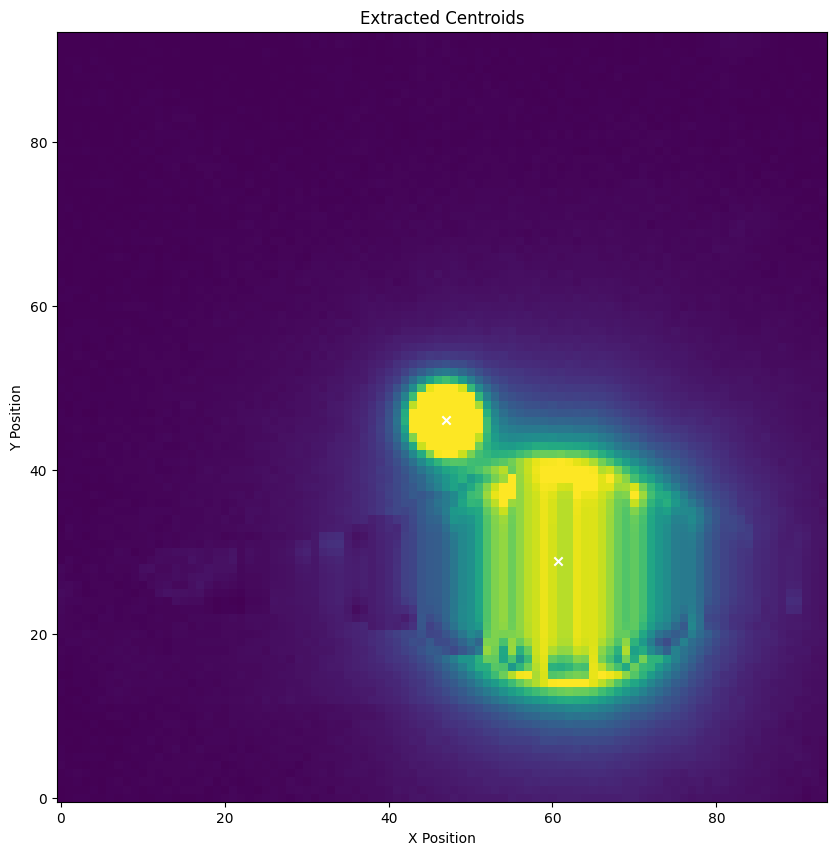

9it [00:01,  5.85it/s]

Image hsc_2626_test_HSC-G/QSO_221811_68_020834_3.fits - Number of sources detected: 3


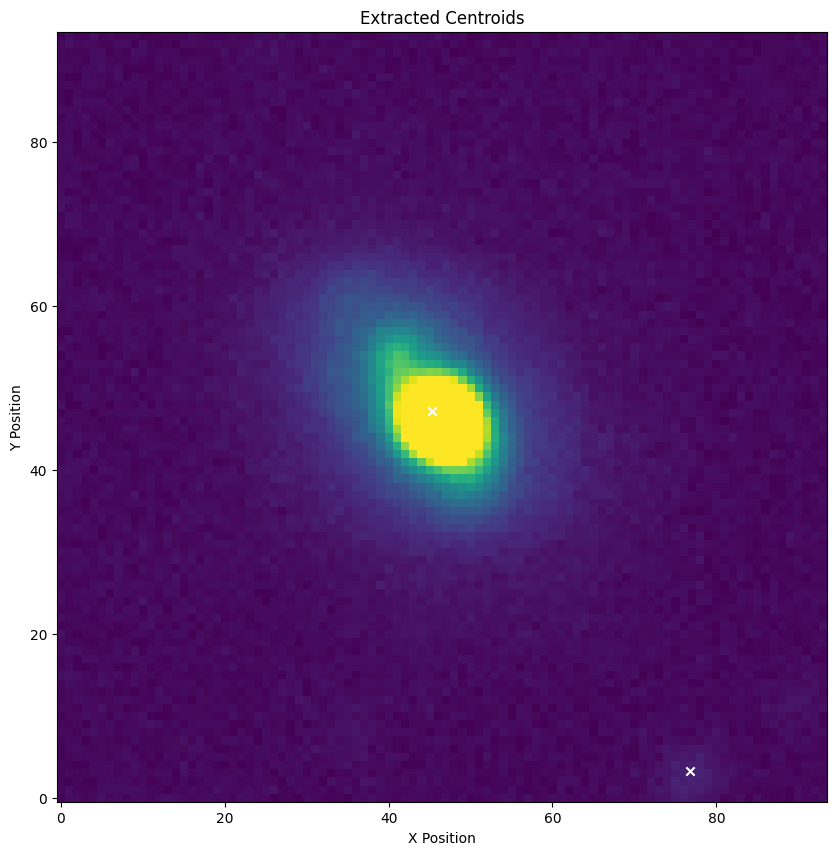

10it [00:01,  5.89it/s]

Image hsc_2626_test_HSC-G/UNK_220546_32_005319_2.fits - Number of sources detected: 20


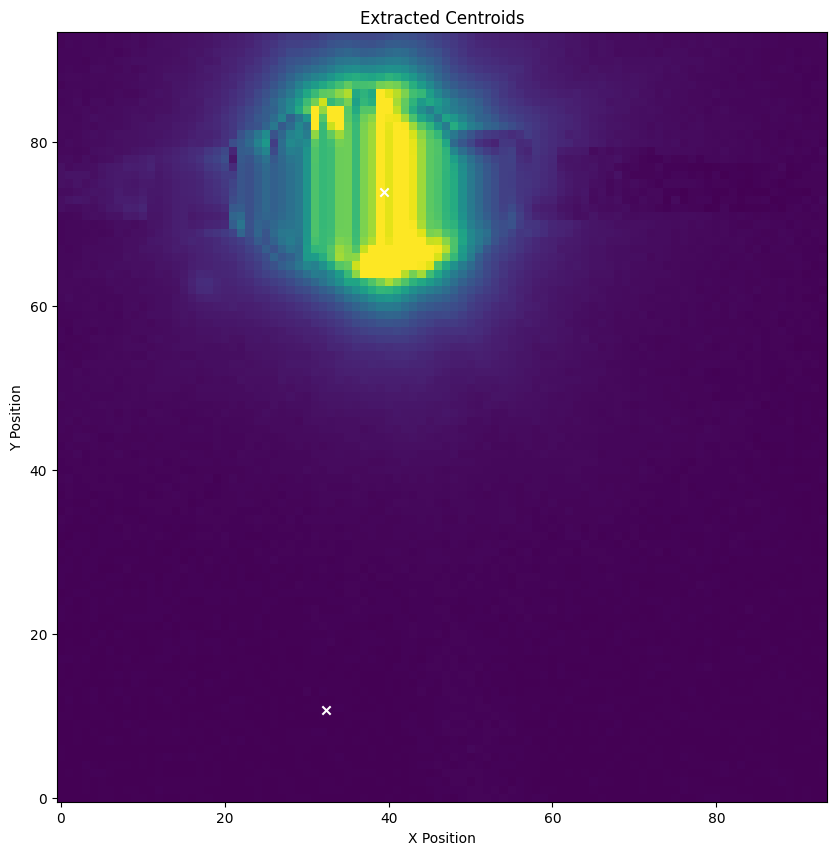

11it [00:01,  5.85it/s]

Image hsc_2626_test_HSC-G/UNK_220905_87_044647_6.fits - Number of sources detected: 2


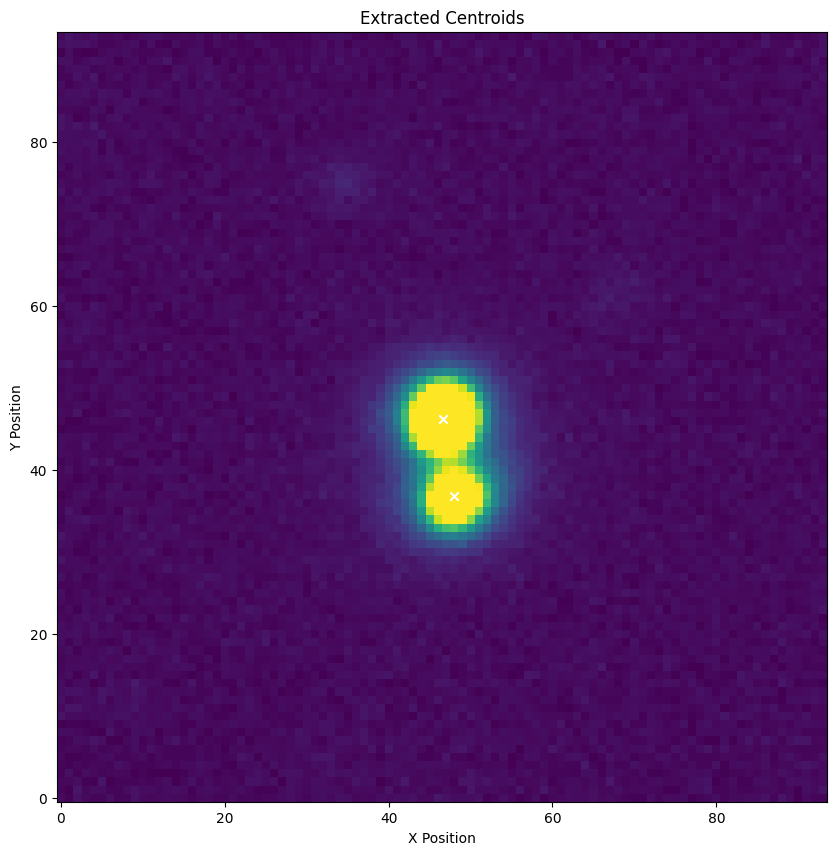

12it [00:02,  5.81it/s]

Image hsc_2626_test_HSC-G/UNK_220906_91_004543_9.fits - Number of sources detected: 102


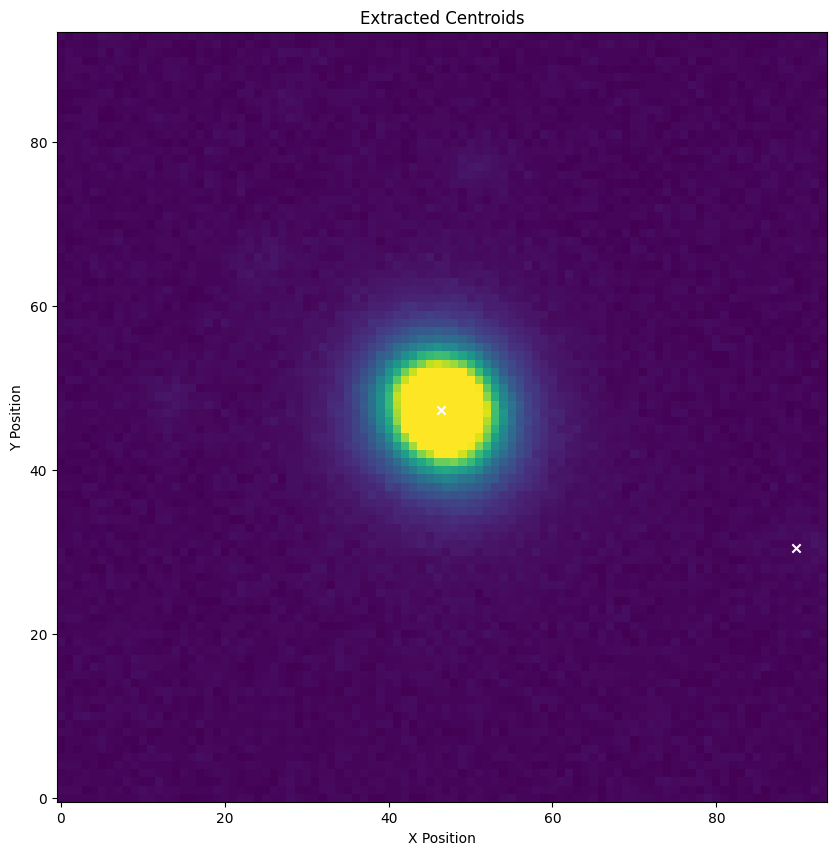

13it [00:02,  5.85it/s]

Image hsc_2626_test_HSC-G/UNK_220946_60_003822_7.fits - Number of sources detected: 21


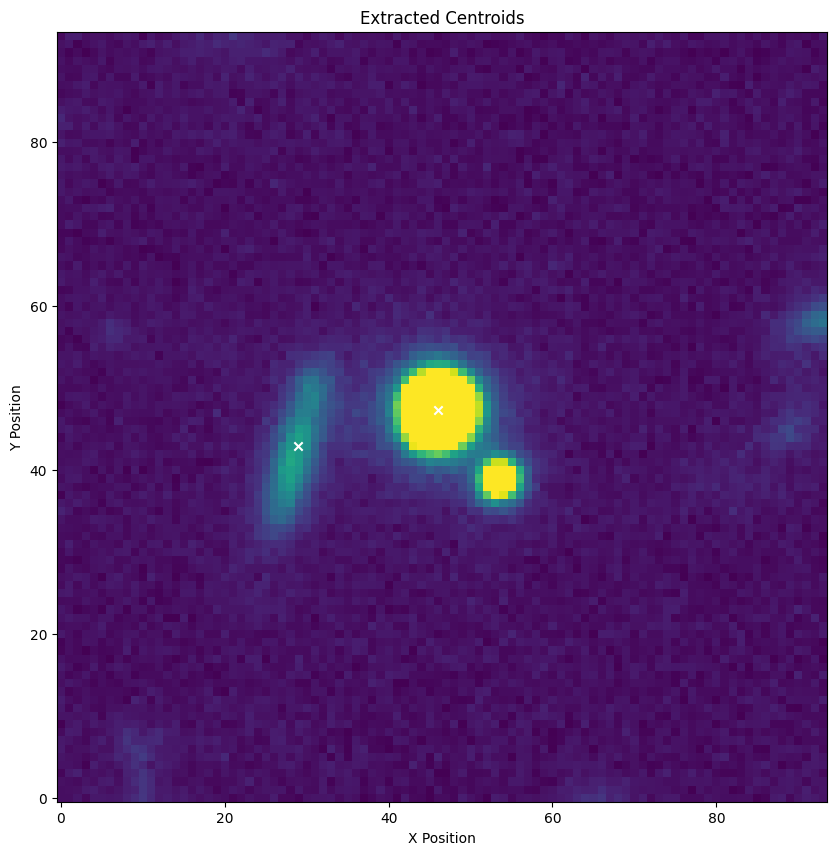

14it [00:02,  5.80it/s]

Image hsc_2626_test_HSC-G/UNK_221115_06_000030_9.fits - Number of sources detected: 61


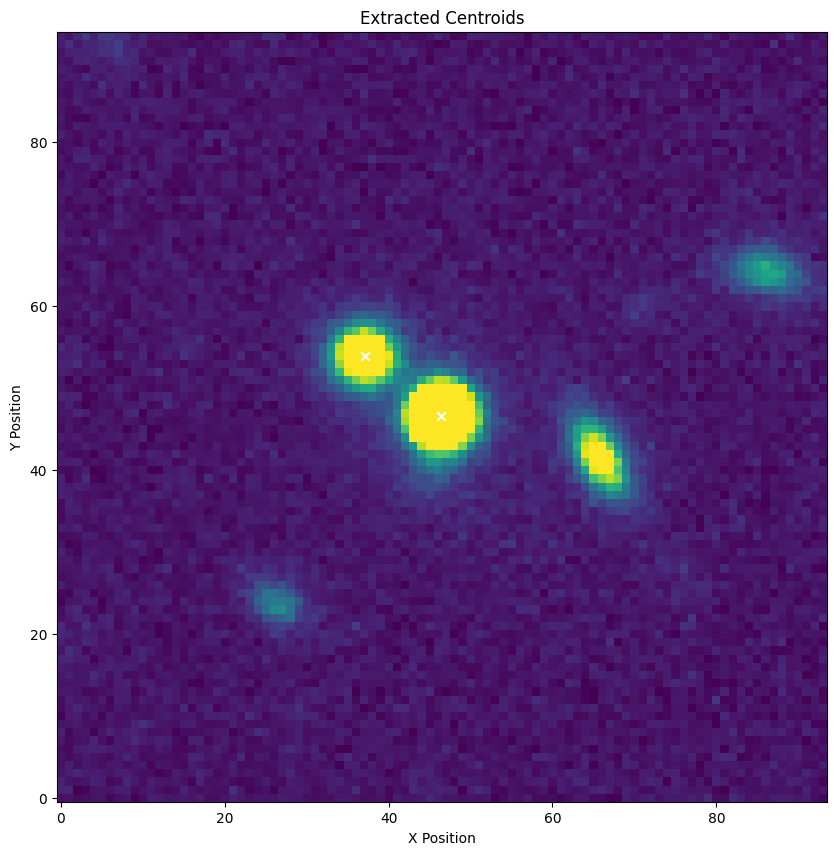

15it [00:02,  5.84it/s]

Image hsc_2626_test_HSC-G/UNK_221926_32_004612_9.fits - Number of sources detected: 59


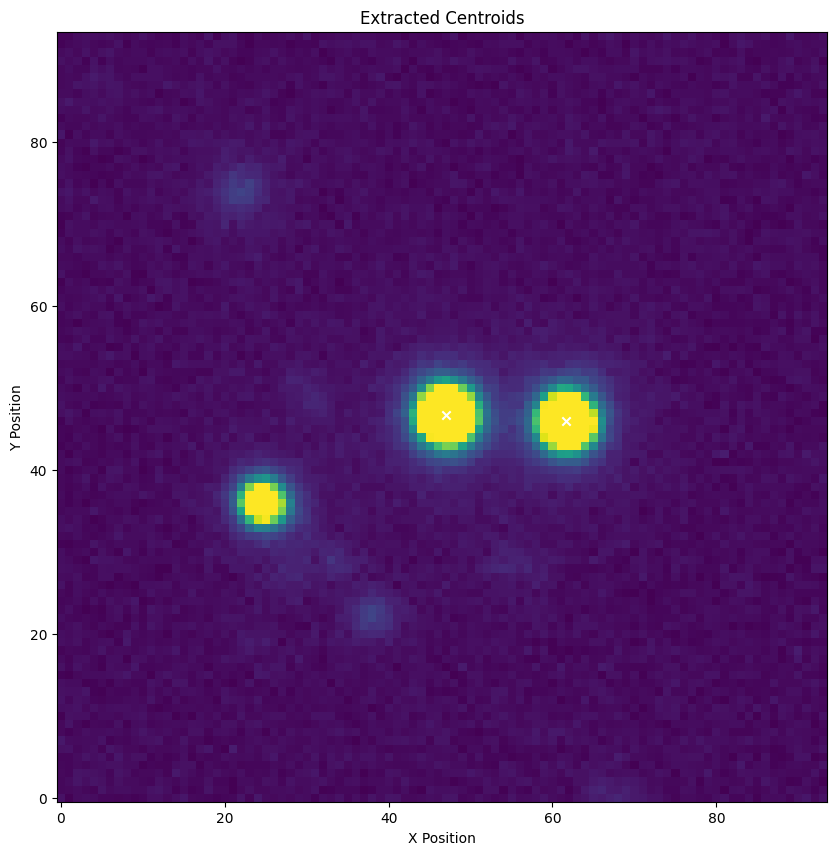

16it [00:02,  5.81it/s]

Image hsc_2626_test_HSC-G/UNK_221956_72_004332_4.fits - Number of sources detected: 57


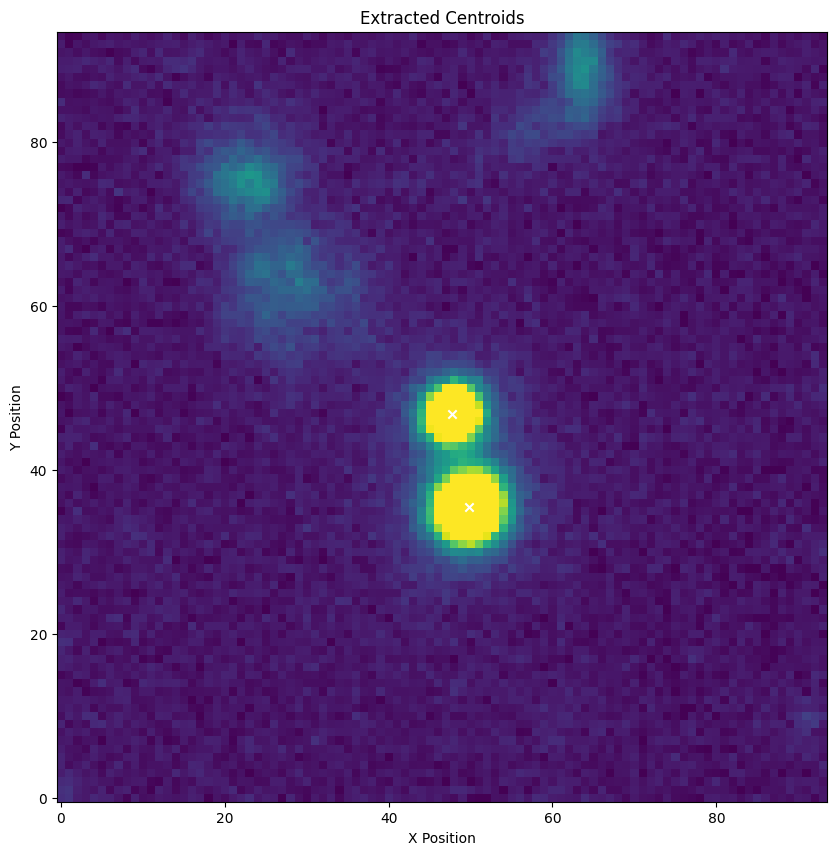

17it [00:02,  5.79it/s]

Image hsc_2626_test_HSC-G/UNK_221958_69_011045_1.fits - Number of sources detected: 55
                                          Object ID  Pixel Separation  \
0   hsc_2626_test_HSC-G/QSO_220522_06_063635_1.fits         52.563376   
1   hsc_2626_test_HSC-G/QSO_220523_55_062640_6.fits         12.590753   
2   hsc_2626_test_HSC-G/QSO_220811_56_023830_1.fits         13.913387   
3   hsc_2626_test_HSC-G/QSO_220858_35_001641_9.fits          7.232409   
4   hsc_2626_test_HSC-G/QSO_221158_06_061614_2.fits         17.782201   
5   hsc_2626_test_HSC-G/QSO_221227_74_005140_7.fits         10.372700   
6   hsc_2626_test_HSC-G/QSO_221258_19_065445_5.fits         55.557077   
7   hsc_2626_test_HSC-G/QSO_221710_61_013808_1.fits         10.662914   
8   hsc_2626_test_HSC-G/QSO_221811_68_020834_3.fits         21.969494   
9   hsc_2626_test_HSC-G/UNK_220546_32_005319_2.fits         54.058577   
10  hsc_2626_test_HSC-G/UNK_220905_87_044647_6.fits         63.539739   
11  hsc_2626_test_HSC-G/UNK_220906_91

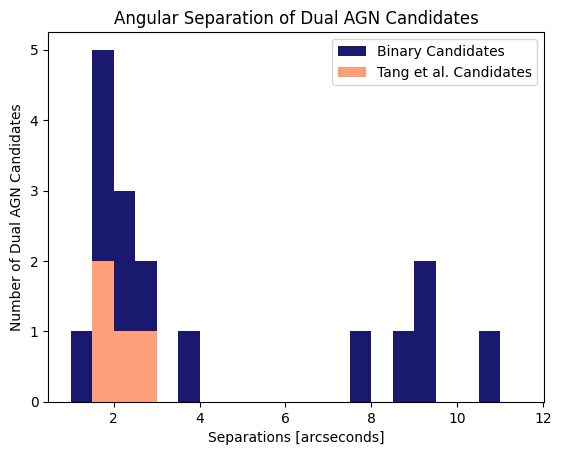

In [4]:
test_instance = testResults(test_images, test_image_names, "hsc_2626_test_HSC-G/")
tes_results = test_instance.test(dual_finder_model)
returned_quasars = test_instance.return_over_80_conf()
test_instance.plot_histogram()
distances, tang_distances, pixel_distances, secondary_quasar_pixel_coordinates, np_doubles, dual_names  = test_instance.find_distances()
physical_distances = []
results_df = pd.read_csv("hsc_2626_test_HSC-G/inf_tensorflow.csv")
fall_df = pd.read_csv("HSC_survey_bands/fall_equitorial_quasar_list.csv")
spring_df = pd.read_csv("HSC_survey_bands/spring_equitorial_quasar_list.csv")
north_df = pd.read_csv("HSC_survey_bands/northern_sky_quasar_list.csv")
candidate_df = pd.read_csv('hsc_2626_test_HSC-G/candidate_info_real.csv')

17it [00:00, 725.07it/s]


skipping: QSO_220522_06_063635_1
45.931951592074824
72.85183408457354
30.276761648022802
22.605366389221608
34.91815164023673
skipping: QSO_221258_19_065445_5
40.650458800563946
32.65123201943785
skipping: UNK_220546_32_005319_2
skipping: UNK_220905_87_044647_6
27.55406100028447
skipping: UNK_220946_60_003822_7
66.25026951463511
skipping: UNK_221926_32_004612_9
skipping: UNK_221956_72_004332_4
28.94435324221983


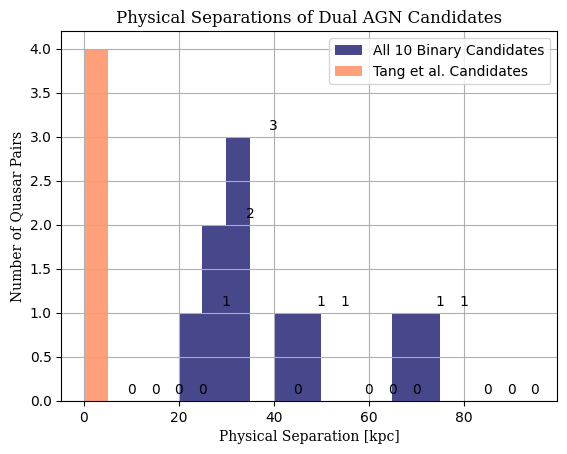

/home/iam37/.conda/envs/DualFinder/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


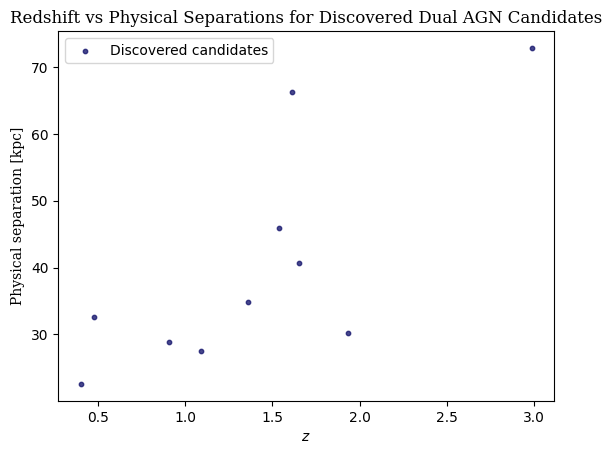

0it [00:00, ?it/s]

(46.54366701822574, 46.47343957252978)
(82.07314198474432, 7.736313889151997)
46.54366701822574
46.47343957252978
Instrumental magnitude 1:  21.644329953402085
Instrumental Magnitude of First Quasar:  21.644329953402085
Instrumental Magnitude of Second Quasar:  24.560700550654854


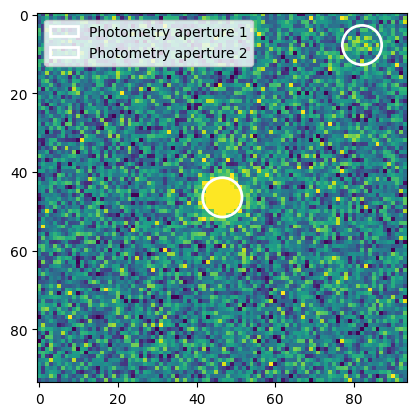

1it [00:00,  7.62it/s]

 id  xcenter  ycenter  aperture_sum
       pix      pix                
--- --------- -------- ------------
  1 46.543667 46.47344    138.76119
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 82.073142 7.7363139    9.4562682
(46.214066919857004, 46.16749609242492)
(56.075569437413705, 53.99551124798533)
46.214066919857004
46.16749609242492
Instrumental magnitude 1:  21.450789005704387
Instrumental Magnitude of First Quasar:  21.450789005704387
Instrumental Magnitude of Second Quasar:  24.236542812356415


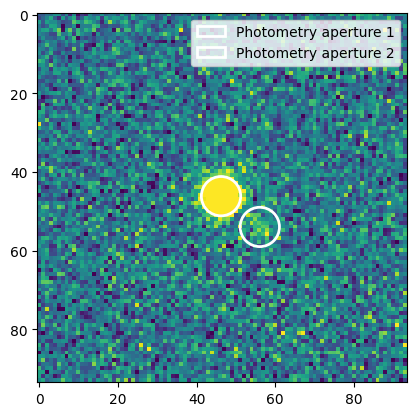

2it [00:00,  7.74it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 46.214067 46.167496    165.83813
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 56.075569 53.995511    12.746263
(54.686804641321366, 34.452247151733005)
(47.09696313153993, 46.11314996127226)
54.686804641321366
34.452247151733005
Instrumental magnitude 1:  20.725340236521617
Instrumental Magnitude of First Quasar:  20.725340236521617
Instrumental Magnitude of Second Quasar:  21.678811143745843


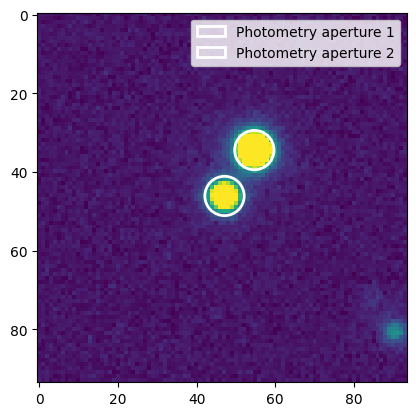

3it [00:00,  7.81it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 54.686805 34.452247    323.49227
 id  xcenter  ycenter  aperture_sum
       pix      pix                
--- --------- -------- ------------
  1 47.096963 46.11315    134.42361
(48.484824068545485, 39.39381298835295)
(46.61868866784424, 46.381321268381676)
48.484824068545485
39.39381298835295
Instrumental magnitude 1:  21.435201848098796
Instrumental Magnitude of First Quasar:  21.435201848098796
Instrumental Magnitude of Second Quasar:  21.55499150546455


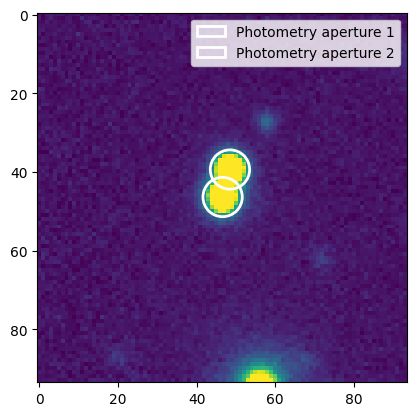

4it [00:00,  7.89it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 48.484824 39.393813    168.23613
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 46.618689 46.381321    150.66189
(52.42667759638415, 63.6601181630128)
(46.29545993095729, 46.96835798786785)
52.42667759638415
63.6601181630128
Instrumental magnitude 1:  21.334786473047103
Instrumental Magnitude of First Quasar:  21.334786473047103
Instrumental Magnitude of Second Quasar:  22.073686980781204


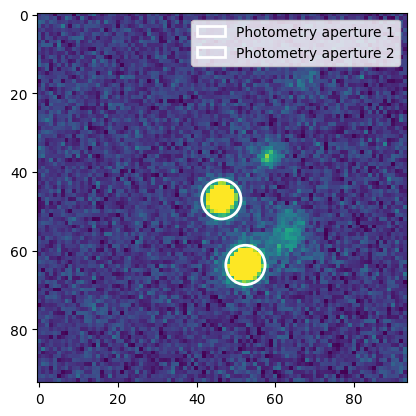

5it [00:00,  7.90it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 52.426678 63.660118    184.53783
 id xcenter   ycenter  aperture_sum
      pix       pix                
--- -------- --------- ------------
  1 46.29546 46.968358     93.43836
(46.2621660262109, 46.008772720304584)
(44.328849497571504, 35.81783559827841)
46.2621660262109
46.008772720304584
Instrumental magnitude 1:  19.539188944265476
Instrumental Magnitude of First Quasar:  19.539188944265476
Instrumental Magnitude of Second Quasar:  21.060111850129168


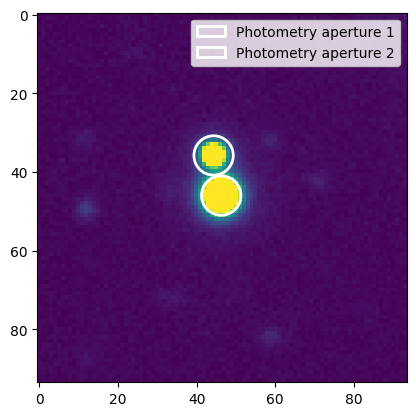

6it [00:00,  7.94it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 46.262166 46.008773    964.54928
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 44.328849 35.817836    237.65954
(47.07974078541848, 46.43174976072303)
(78.96823091718794, 91.92584812641971)
47.07974078541848
46.43174976072303
Instrumental magnitude 1:  20.557471417519903
Instrumental Magnitude of First Quasar:  20.557471417519903
Instrumental Magnitude of Second Quasar:  25.380192312999903


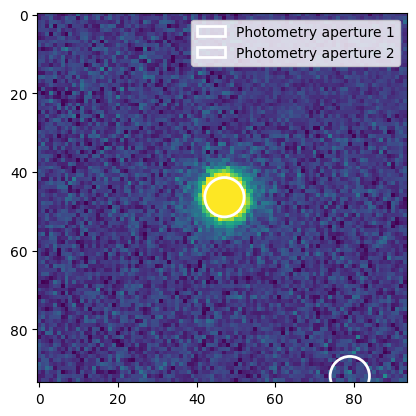

7it [00:00,  7.93it/s]

 id  xcenter  ycenter  aperture_sum
       pix      pix                
--- --------- -------- ------------
  1 47.079741 46.43175    377.58213
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 78.968231 91.925848    4.4455252
(46.300601897717954, 45.98050535269298)
(47.46868584085712, 56.579246917408064)
46.300601897717954
45.98050535269298
Instrumental magnitude 1:  19.254445642573003
Instrumental Magnitude of First Quasar:  19.254445642573003
Instrumental Magnitude of Second Quasar:  20.88959485676639


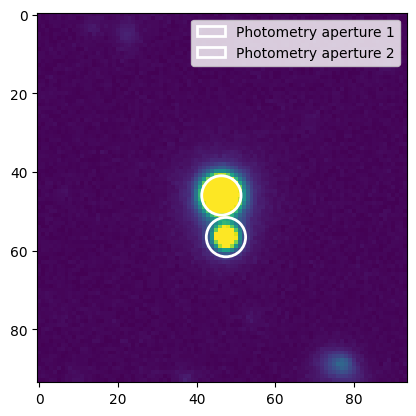

8it [00:01,  7.97it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 46.300602 45.980505    1253.7812
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 47.468686 56.579247    278.07507
(60.61587886546697, 28.863631441967208)
(47.009228643426745, 46.112333829682896)
60.61587886546697
28.863631441967208
Instrumental magnitude 1:  19.608866096395722
Instrumental Magnitude of First Quasar:  19.608866096395722
Instrumental Magnitude of Second Quasar:  18.702557263269625


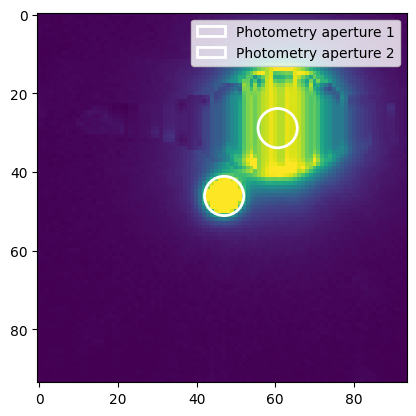

9it [00:01,  7.94it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 60.615879 28.863631    904.59371
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 47.009229 46.112334    2084.3809
(45.332478921392806, 47.205625570560606)
(76.73486619733129, 3.2031272496298446)
45.332478921392806
47.205625570560606
Instrumental magnitude 1:  20.287939016177504
Instrumental Magnitude of First Quasar:  20.287939016177504
Instrumental Magnitude of Second Quasar:  24.824567271420158


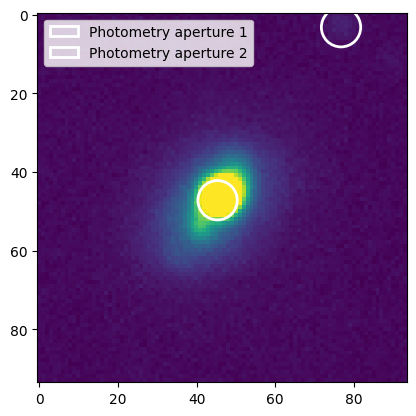

10it [00:01,  7.95it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 45.332479 47.205626    483.97663
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 76.734866 3.2031272    7.4160576
(39.44744479661557, 73.87425276076443)
(32.294973348540736, 10.738362788798907)
39.44744479661557
73.87425276076443
Instrumental magnitude 1:  19.276180269640967
Instrumental Magnitude of First Quasar:  19.276180269640967
Instrumental Magnitude of Second Quasar:  26.087948346010975


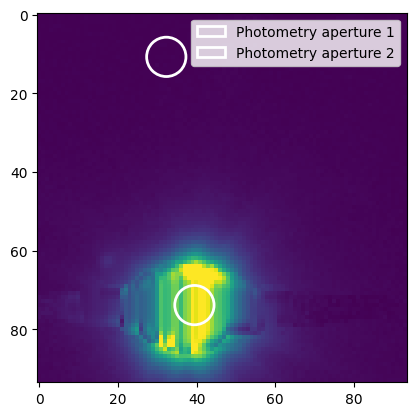

11it [00:01,  7.95it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 39.447445 73.874253    1228.9321
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 32.294973 10.738363    2.3164379
(46.637131583272286, 46.24354354209918)
(48.00574273521345, 36.820731899314715)
46.637131583272286
46.24354354209918
Instrumental magnitude 1:  20.72200070938417
Instrumental Magnitude of First Quasar:  20.72200070938417
Instrumental Magnitude of Second Quasar:  21.40308285684491


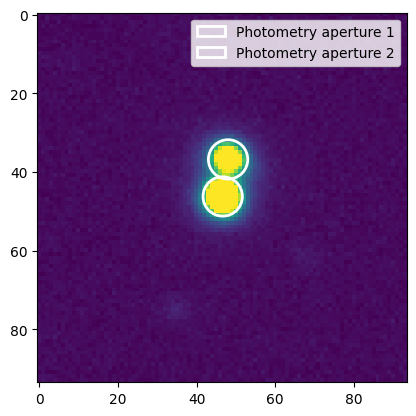

12it [00:01,  7.98it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 46.637132 46.243544     324.4888
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 48.005743 36.820732    173.28735
(46.358805615622266, 47.363077175327824)
(89.72165379136587, 30.514582291325777)
46.358805615622266
47.363077175327824
Instrumental magnitude 1:  19.838619622903128
Instrumental Magnitude of First Quasar:  19.838619622903128
Instrumental Magnitude of Second Quasar:  25.653047351245274


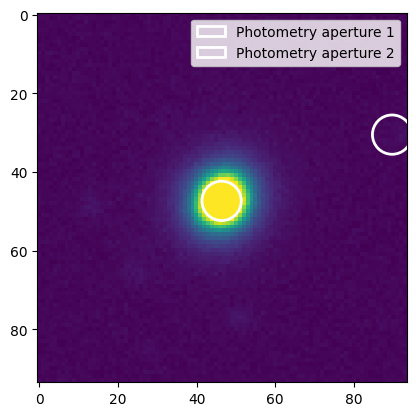

13it [00:01,  7.96it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 46.358806 47.363077    732.06923
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 89.721654 30.514582    3.4576502
(46.00787992615829, 47.30431312366369)
(28.939604923537765, 42.94524219935898)
46.00787992615829
47.30431312366369
Instrumental magnitude 1:  19.886552550509418
Instrumental Magnitude of First Quasar:  19.886552550509418
Instrumental Magnitude of Second Quasar:  23.033621716616864


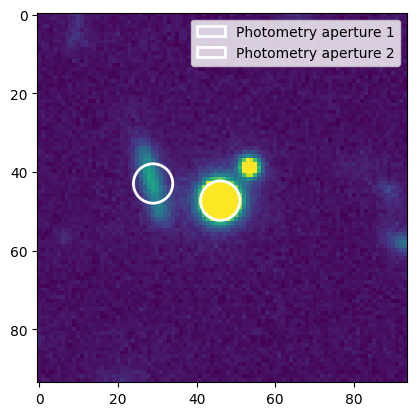

14it [00:01,  7.99it/s]

 id xcenter   ycenter  aperture_sum
      pix       pix                
--- -------- --------- ------------
  1 46.00788 47.304313    700.45297
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 28.939605 42.945242    38.596801
(46.342198677812014, 46.563698190955435)
(37.136901189392624, 53.87850828345676)
46.342198677812014
46.563698190955435
Instrumental magnitude 1:  20.225944930210655
Instrumental Magnitude of First Quasar:  20.225944930210655
Instrumental Magnitude of Second Quasar:  21.8755614054496


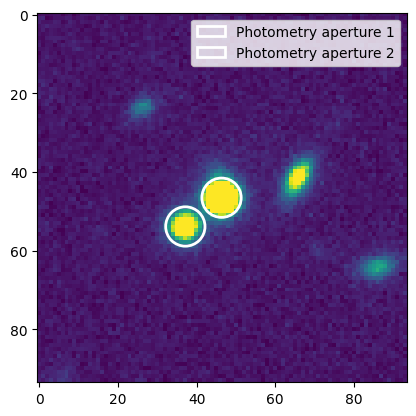

15it [00:01,  7.91it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 46.342199 46.563698    512.41523
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 37.136901 53.878508    112.14384
(47.05944853248368, 46.734778152416126)
(61.647555800429394, 46.03198575957965)
47.05944853248368
46.734778152416126
Instrumental magnitude 1:  20.771405100110133
Instrumental Magnitude of First Quasar:  20.771405100110133
Instrumental Magnitude of Second Quasar:  20.952133033749444


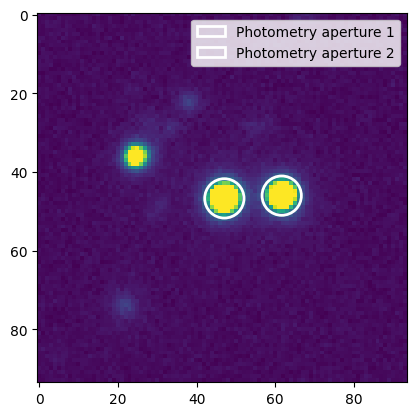

16it [00:02,  7.95it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 47.059449 46.734778    310.05444
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 61.647556 46.031986    262.51056
(49.74773602298188, 35.51753295223038)
(47.76797897060244, 46.80229314382956)
49.74773602298188
35.51753295223038
Instrumental magnitude 1:  21.28372611029311
Instrumental Magnitude of First Quasar:  21.28372611029311
Instrumental Magnitude of Second Quasar:  21.697582663170685


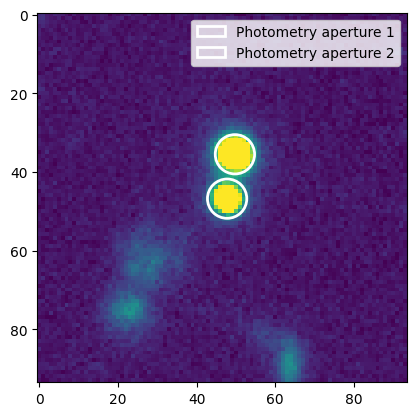

17it [00:02,  7.93it/s]

 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 49.747736 35.517533    193.42364
 id  xcenter   ycenter  aperture_sum
       pix       pix                
--- --------- --------- ------------
  1 47.767979 46.802293     132.1195


In [5]:
redshifts = []
physical_distances = []
for ii, distance in tqdm(enumerate(distances)):
    input_name = dual_names[ii][20:-5].strip()
    #print(input_name)
    quasar_row = candidate_df[candidate_df['name'] == input_name]
    if not quasar_row.empty:
        #print(quasar_row)
        ra = quasar_row['ra']
        dec = quasar_row['dec']
        z = quasar_row['redshift']
        redshifts.append(z)
        #print(f"RA: {ra}, Dec: {dec}")
        physical_sep = test_instance.find_physical_separations(ra, dec, z, distance)
        print(physical_sep[0])
        physical_distances.append(physical_sep[0])
    else:
        print(f"skipping: {input_name}")
        continue
#test_instance.plot_physical_separation(physical_distances, redshifts = redshifts, angular_separations = distances, tang_physical_separations = tang_distances)
test_instance.plot_physical_separation(physical_distances, redshifts = redshifts, tang_physical_separations = tang_distances)
inst_mags_center = []
inst_mags_secondary = []
flux_ratios = []
magnitude_diffs = []
flux_mag_0 = 63095734448.01944 # placeholder to see if this value works for ALL images. 
for ii, dual_image in tqdm(enumerate(np_doubles)):
    center_coords = secondary_quasar_pixel_coordinates[ii][0]
    print(center_coords)
    secondary_coords = secondary_quasar_pixel_coordinates[ii][1]
    print(secondary_coords)
    inst_mag_1, inst_mag_2, flux_ratio, mag_difference = test_instance.quasar_photometry(dual_image, center_coords, secondary_coords, flux_mag_0)
    inst_mags_center.append(inst_mag_1)
    inst_mags_secondary.append(inst_mag_2)
    flux_ratios.append(flux_ratio)
    magnitude_diffs.append(mag_difference)

